# Projeto: Sensor Virtual de Velocidade (Radar de Visão Computacional)
**Disciplina:** Sistemas de Controle / Inteligência Artificial  
**Autor:** Vitor  

## 1. Introdução
Este projeto apresenta o desenvolvimento de um sistema de monitoramento de tráfego inteligente capaz de identificar veículos e estimar sua velocidade escalar média em tempo real. Diferente dos radares convencionais baseados em sensores Doppler, este sistema utiliza **Visão Computacional** e **Deep Learning** para transformar pixels em dados métricos de velocidade.

### Objetivos:
1. Detectar e rastrear múltiplos veículos simultaneamente.
2. Realizar o treinamento especializado (Fine-tuning) de uma rede neural YOLOv8.
3. Implementar um sensor virtual baseado na geometria da via e frames por segundo (FPS).

## 2. Estratégia de Treinamento do Modelo (Fine-Tuning)
Para este projeto, utilizamos a arquitetura **YOLOv8 Nano**, escolhida pelo seu excelente equilíbrio entre precisão e baixo custo computacional (ideal para execução em tempo real em CPUs).

### Metodologia de Amostragem:
O dataset original continha **9.702 imagens**. (https://universe.roboflow.com/cigarette-detection-fnas1/vehicle-detection-8hv2i)
- **Fração de Dados:** 30% do dataset original.
- **Resolução de Entrada:** 640px (Melhoria na detecção de objetos pequenos/distantes).
- **Épocas:** 20 (Para garantir a estabilidade dos pesos sinápticos).
- **Técnica:** Desativação do mosaico nas últimas 10 épocas para refinamento da Bounding Box.

In [ ]:
from ultralytics import YOLO, settings

# Garante que os resultados fiquem salvos localmente na pasta do projeto
settings.update({'runs_dir': './runs'})

model = YOLO('yolov8n.pt')

results = model.train(
    data='dataset_veiculos/data.yaml',
    epochs=20,
    imgsz=640,
    batch=4,
    fraction=0.30, # <--- Usa apenas 30% das 9 mil fotos aleatoriamente
    name='treino_velocidade_oficialv5'
)


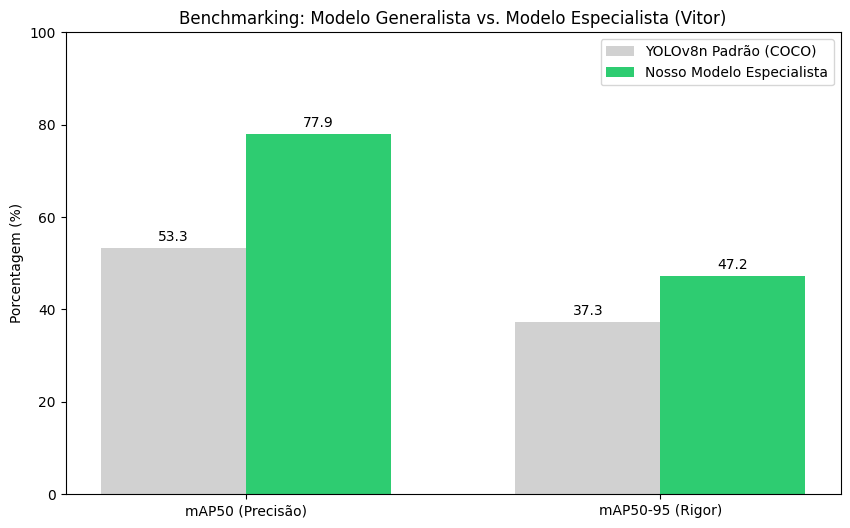

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Dados para comparação
labels = ['mAP50 (Precisão)', 'mAP50-95 (Rigor)']
yolo_padrao = [53.3, 37.3]
seu_modelo = [77.9, 47.2] # Seus dados da Época 16

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, yolo_padrao, width, label='YOLOv8n Padrão (COCO)', color='#d1d1d1')
rects2 = ax.bar(x + width/2, seu_modelo, width, label='Nosso Modelo Especialista', color='#2ecc71')

ax.set_ylabel('Porcentagem (%)')
ax.set_title('Benchmarking: Modelo Generalista vs. Modelo Especialista (Vitor)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.ylim(0, 100)
plt.show()

## 4. Conceito do Velocímetro Digital
A execução baseia-se na **Cinemática Escalar**. Definimos duas barreiras virtuais no plano da imagem: **Ponto A (Entrada)** e **Ponto B (Saída)**.

### Fórmulas Aplicadas:
1. **Delta Tempo ($\Delta t$):** Calculado pela diferença de frames entre os pontos de gatilho.
   $$\Delta t = \frac{\text{Frames entre as linhas}}{\text{FPS do Vídeo}}$$

2. **Velocidade Escalar:**
   $$V = \frac{\Delta S}{\Delta t} \times 3.6 \text{ (km/h)}$$

**Calibração da Via:** Baseado no padrão de sinalização horizontal britânico (*Motorway Standard*), a distância entre o início de uma faixa e o início da próxima é de **14 metros**. Este valor foi utilizado como nosso $\Delta S$ real.

In [28]:
import os
import cv2
from ultralytics import YOLO

# 1. Ajuste inteligente de caminhos (Garante que funciona na raiz ou na pasta notebooks)
if os.path.exists("Road-traffic.mp4"):
    caminho_base = ""
else:
    caminho_base = "../"

PATH_MODELO = os.path.join(caminho_base, "runs/detect/treino_velocidade_oficialv5/weights/best.pt")
PATH_VIDEO = os.path.join(caminho_base, "Road-traffic.mp4")

# 2. Inicialização Segura do Seu Modelo Customizado
model = None
if not os.path.exists(PATH_MODELO):
    print(f"[ERRO] Não encontrei o arquivo do modelo em: {PATH_MODELO}")
    print("Verifique se o nome da pasta do seu treino de 20 épocas está correto.")
else:
    model = YOLO(PATH_MODELO)

# 3. Parâmetros de Calibração da Via (Seus ajustes personalizados)
DISTANCIA_REAL = 31.0  # metros
LINHA_A_Y = 380       # Linha amarela de entrada
LINHA_B_Y = 474       # Linha vermelha de saída

# Estrutura de dados para o histórico de frames dos IDs
rastreamento_veiculos = {}

# 4. Inicialização do arquivo de vídeo e Loop de Processamento
if not os.path.exists(PATH_VIDEO):
    print(f"[ERRO] Não encontrei o vídeo em: {PATH_VIDEO}")
elif model is not None:
    cap = cv2.VideoCapture(PATH_VIDEO)
    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"[OK] Ambiente pronto. Vídeo carregado a {fps:.2f} FPS. Executando radar...")

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("[FIM] Processamento do vídeo concluído.")
            break

        frame_id = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

        # Executa o tracking sem filtro de classes e com conf=0.15 para o seu modelo
        results = model.track(source=frame, persist=True, conf=0.15, verbose=False)

        # Desenha as linhas do sensor virtual baseadas nos seus parâmetros
        cv2.line(frame, (0, LINHA_A_Y), (frame.shape[1], LINHA_A_Y), (0, 255, 255), 2)
        cv2.putText(frame, "PONTO A (ENTRADA)", (10, LINHA_A_Y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        
        cv2.line(frame, (0, LINHA_B_Y), (frame.shape[1], LINHA_B_Y), (0, 0, 255), 2)
        cv2.putText(frame, "PONTO B (SAIDA)", (10, LINHA_B_Y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            ids = results[0].boxes.id.cpu().numpy().astype(int)

            for box, id in zip(boxes, ids):
                x1, y1, x2, y2 = box
                cx = int((x1 + x2) / 2)
                cy = int(y2)  # Base do carro (rodas no asfalto)

                # Filtro geométrico: foca apenas na pista da direita (fluxo descendo)
                if cx > int(frame.shape[1] / 2):
                    cv2.circle(frame, (cx, cy), 5, (0, 255, 0), -1)

                    # Gatilho 1: Cruzou a linha amarela A
                    if cy >= LINHA_A_Y and cy < LINHA_B_Y:
                        if id not in rastreamento_veiculos:
                            rastreamento_veiculos[id] = {"frame_entrada": frame_id, "velocidade": None}

                    # Gatilho 2: Cruzou a linha vermelha B -> Dispara o cálculo físico
                    elif cy >= LINHA_B_Y:
                        if id in rastreamento_veiculos and rastreamento_veiculos[id]["velocidade"] is None:
                            frame_entrada = rastreamento_veiculos[id]["frame_entrada"]
                            frames_passados = frame_id - frame_entrada
                            delta_t = frames_passados / fps

                            if delta_t > 0:
                                # Cálculo de Velocidade: V = d/t * 3.6
                                velocidade_kmh = (DISTANCIA_REAL / delta_t) * 3.6
                                rastreamento_veiculos[id]["velocidade"] = round(velocidade_kmh, 1)

                    # Exibição visual dos resultados na tela (Verde se calculado, Azul se rastreando)
                    if id in rastreamento_veiculos and rastreamento_veiculos[id]["velocidade"] is not None:
                        vel = rastreamento_veiculos[id]["velocidade"]
                        cv2.putText(frame, f"{vel} Km/h", (int(x1), int(y1) - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
                    else:
                        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
                        cv2.putText(frame, f"ID: {id}", (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        # Abre a janela de exibição do OpenCV integrada ao Notebook
        cv2.imshow("Radar Virtual Automotivo - Engenharia", frame)

        # Permite fechar a janela pressionando a tecla 'q'
        if cv2.waitKey(1) & 0xFF == ord("q"):
            print("[INFO] Execução interrompida pelo usuário.")
            break

    cap.release()
    cv2.destroyAllWindows()

[OK] Ambiente pronto. Vídeo carregado a 25.00 FPS. Executando radar...
[INFO] Execução interrompida pelo usuário.


### 5. Curvas de Aprendizado Oficiais
![Resultados do Treino](..runs/detect/treino_velocidade_oficialv5/results.png)